# Stochastic Gradient Descent (SGD)


*Dataset example: (Linear data) Housing market. (X) the size of the houses, (Y) labels for the corresponding prices of the houses*

SGD is an optimization algorithm that is particularly used with large datasets, especially if you can not fit the entire dataset into memory. Its update rule runs **once per sample/mini-batch** (once per house/or a batch of houses), instead of once per the entire dataset ([BGD](batch_gradient_descent.ipynb)).

$$\theta = \theta - \alpha \Delta_{\theta} C(\theta; x_i,y_i)$$


Where:
- $x_i, y_i$ represent the features and labels for the $i$-th training sample.
- $C$ represents the cost function.
- $\Delta_{\theta} C(\theta; x_i,y_i)$ is the gradient of the cost function with respect to the parameter ($\theta$, which is either $w$ or $b$) , which is calculated for a single sample, i.e., just one house's data.
- $\alpha$ is called 'alpha', it is the learning rate.
- SGD is very noisy, i.e., its path to 'global' or 'local minima', meaning that the path can look like a 'zig-zag' compared to a smooth and direct path of BGD. This is because SGD updates per sample or mini-batch. This noise is good, because it can help the algorithm jump out of a shallow local minima and find a better, deeper one!
  - Noise path to minima:
        <p align="center">
            <img src="./showcase_images/SGD_vs_BGD.png" alt="SGD vs BGD noise math" width="70%">
        </p>

- In code $\Delta_{\theta} C$ is the gradient vector, which is calculated using its partial derivatives: 
  - `dC/dw = 2 * error * xi` (which is $\Delta_w C$)
  - `dC/db = 2 * error` (which is $\Delta_b C$)

### Code Example (With Linear Regression)

**Task:** Fit a line to the housing market data.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create dummy housing market dataset, the dataset contains 100 houses
X = np.random.rand(100, 1) # 100 values between 0 and 1
Y = X + np.random.rand(100, 1) * 0.2 # y = X + noise # The prices are between 0 and 1 to keep the weights from exploding!
num_samples = len(X)

In [10]:
batch_size = 1 # Model sees one house at a time!
num_epochs = 30
learning_rate = 0.01

In [11]:
# Initialize a weight and a bias
w = np.random.randn(1,1)
b = np.random.randn(1,1)
w, b

(array([[0.10923693]]), array([[-0.26321886]]))

In [12]:
costs = []

# See how well the model performs before training
all_preds = X.dot(w) + b
all_errors = all_preds - Y
initial_cost = np.mean(all_errors**2)
print(f"Cost before training: {initial_cost:.4f}\n\n")


# Train loop
for epoch in range(num_epochs):
    for oneHouse in range(num_samples):
        # Get the houses price and its label
        xi = X[oneHouse : oneHouse + 1]
        yi = Y[oneHouse : oneHouse + 1]

        # Predict w*x+b
        pred = xi.dot(w) + b

        # Compute the error for this one sample
        error = pred - yi

        # Calculate the gradient for this one sample: C = error^2
        # dC/dw = 2 * error * xi
        # dC/db = 2 * error
        grad_w = 2 * xi.T.dot(error)
        grad_b = 2 * np.sum(error)

        # Update the parameters using: θ = θ - alpha * ΔC
        w = w - learning_rate * grad_w
        b = b - learning_rate * grad_b

    # After each epoch calculate the total cost using (MSE) over the entire dataset, to see how well the model is doing.
    all_preds = X.dot(w) + b

    all_errors = all_preds - Y
    mean_cost = np.mean(all_errors**2)  # (MSE)

    # Record the cost every 10 epochs
    if epoch % 10 == 0:
        costs.append(mean_cost)
        print(f"Cost after epoch {epoch}: {mean_cost.item():.4f}")

print("\n\nTraining Finished")
print(f"    Results → weight: {w[0][0]:.4f} bias: {b[0][0]:.4f}")

Cost before training: 0.7617


Cost after epoch 0: 0.0236
Cost after epoch 10: 0.0048
Cost after epoch 20: 0.0032


Training Finished
    Results → weight: 0.9991 bias: 0.0927


In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(X, Y, alpha=0.6, label="Housing market data points")

# Add the fitted line
plt.plot(X, X.dot(w) + b, color='purple', linewidth=3, label="Fitted line (SGD)")

plt.title("SGD for Linear Regression (Normalized Data)")
plt.xlabel("Housing size (Normalized)")
plt.ylabel("Housing Prices (Normalized)")
plt.legend()
plt.show()


Plot the **Cost** error

Text(0.5, 0, 'Epoch (per 10)')

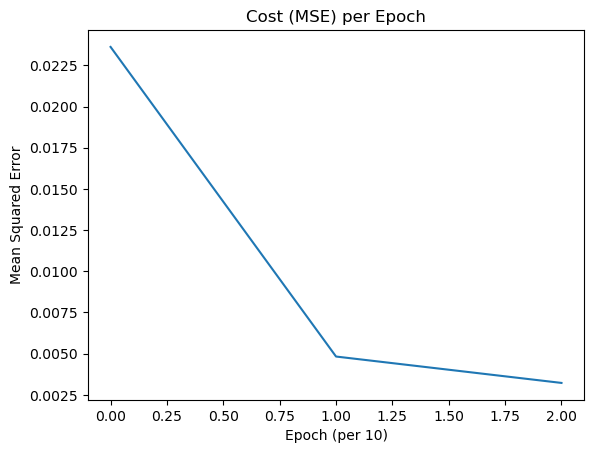

In [14]:
plt.plot(costs)
plt.title("Cost (MSE) per Epoch")
plt.ylabel("Mean Squared Error")
plt.xlabel("Epoch (per 10)")